In [1]:
import pandas as pd

df = pd.read_csv('capston_filled.csv')
display(df.head())

,Unnamed: 0,SEQID,PROVID,GRADE,DVGENDER,DVURBAN,DVRES,GH_010,GH_020,SS_010,...,BEH_010,BEH_020,BUL_010,BUL_020,BUL_030,BUL_040,DVTY1ST,DVTY2ST,DVLAST30,DVAMTSMK
0,0,18338.0,Prince Edward Island,9,2,1,3,2,3,2,...,1,1,2,1,2,2,3,7,2,0
1,1,16111.0,Quebec,10,1,1,1,3,3,2,...,3,4,2,2,2,2,3,7,2,0
2,2,20587.0,Newfoundland and Labrador,7,2,1,1,2,1,2,...,4,4,2,2,2,2,3,7,2,0
3,3,54568.0,Nova Scotia,8,2,2,1,4,5,2,...,4,4,1,2,2,2,3,7,2,0
4,4,401.0,Newfoundland and Labrador,7,1,2,1,2,3,2,...,4,4,2,2,2,2,3,7,2,0


In [2]:
# Calculate the number of missing values in each column
missing_values = df.isnull().sum()

# Display the results
print("Missing Values in Each Column:")
missing_values


Missing Values in Each Column:


,0
Unnamed: 0,0
SEQID,2
PROVID,0
GRADE,0
DVGENDER,0
DVURBAN,0
DVRES,0
GH_010,0
GH_020,0
SS_010,0


#Comparative Analysis

Compare Smoking Behavior of Ontario, Quebec, and British Columbia

In [3]:
# Cross Tabulation of SS_010 (Smoker), TS_011(Will smoke in Future), DVTY1ST(Smoking Status), DVTY2ST (Smoking Status in detailed), DVLAST30, DVAMTSMK (average umber of cigarettes smoked) for "PROVID": Quebec, British Columbia and Ontario. For each variable, make a table (with both count and percentage distribution) and conduct Chisq test

import pandas as pd
from scipy.stats import chi2_contingency

# Assuming 'df' is your DataFrame and it's already loaded

provinces = ['Quebec', 'British Columbia', 'Ontario']
variables = ['SS_010', 'TS_011', 'DVTY1ST', 'DVTY2ST', 'DVLAST30', 'DVAMTSMK']

for var in variables:
  for province in provinces:
    # Create a cross-tabulation table
    crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
    crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100

    print(f"\nCross-tabulation for {var} in {province}:")
    print(crosstab)

for var in variables:
    crosstab_all = pd.crosstab(df['PROVID'], df[var], normalize='index') * 100  # Percentage for each province
    print(f"\nCross-tabulation for {var} across all provinces (percentage):")
    print(crosstab_all.loc[provinces]) #show only specified provinces

    for province in provinces:
        # Create a cross-tabulation table
        crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
        crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100
        print(f"\nCross-tabulation for {var} in {province}:")
        print(crosstab)



    # Conduct Chi-square test (if applicable)
    contingency_table = pd.crosstab(df[df['PROVID'] == province]['SS_010'], df[df['PROVID'] == province][var])
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1: #Check if contingency table is valid
      chi2, p, dof, expected = chi2_contingency(contingency_table)
      print(f"\nChi-square test for {var} in {province}:")
      print(f"Chi2 statistic: {chi2}")
      print(f"P-value: {p}")
      print(f"Degrees of freedom: {dof}")
    else:
      print(f"\nChi-square test not applicable for {var} in {province} due to insufficient data in contingency table.")



Cross-tabulation for SS_010 in Quebec:
col_0   count  percentage
SS_010                   
1        1615    14.86698
2        9248    85.13302

Cross-tabulation for SS_010 in British Columbia:
col_0   count  percentage
SS_010                   
1        1068   15.511983
2        5817   84.488017

Cross-tabulation for SS_010 in Ontario:
col_0   count  percentage
SS_010                   
1         849   12.587102
2        5896   87.412898

Cross-tabulation for TS_011 in Quebec:
col_0   count  percentage
TS_011                   
1         276    2.540735
2         394    3.626991
3        1670   15.373285
4        8523   78.458989

Cross-tabulation for TS_011 in British Columbia:
col_0   count  percentage
TS_011                   
1         231    3.355120
2         349    5.068991
3        1455   21.132898
4        4850   70.442992

Cross-tabulation for TS_011 in Ontario:
col_0   count  percentage
TS_011                   
1         200    2.965159
2         275    4.077094
3        1


--- Analysis for variable: SS_010 ---

Percentage Distribution of SS_010 by Province:


SS_010,1,2
PROVID,,
Quebec,14.866980,85.133020
British Columbia,15.511983,84.488017
Ontario,12.587102,87.412898


<Figure size 1000x600 with 0 Axes>

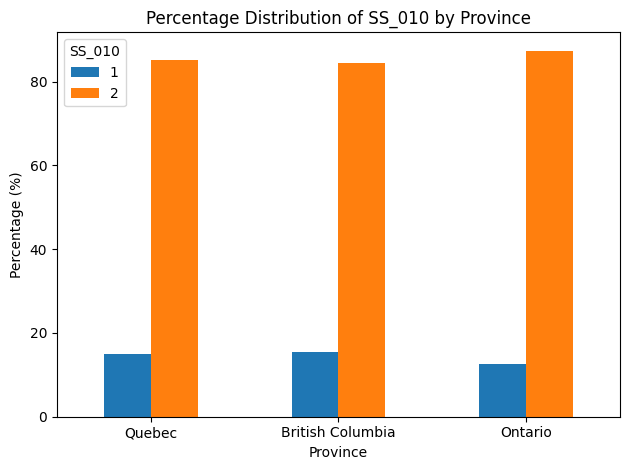


Chi-square test for SS_010 across Quebec, British Columbia, Ontario:
Chi2 statistic: 26.77274047539199
P-value: 1.5359365423046068e-06
Degrees of freedom: 2
Expected frequencies:
SS_010                      1            2
PROVID                                    
British Columbia   992.847752  5892.152248
Ontario            972.659127  5772.340873
Quebec            1566.493120  9296.506880

--- Analysis for variable: TS_011 ---

Percentage Distribution of TS_011 by Province:


TS_011,1,2,3,4
PROVID,,,,
Quebec,2.540735,3.626991,15.373285,78.458989
British Columbia,3.355120,5.068991,21.132898,70.442992
Ontario,2.965159,4.077094,17.183099,75.774648


<Figure size 1000x600 with 0 Axes>

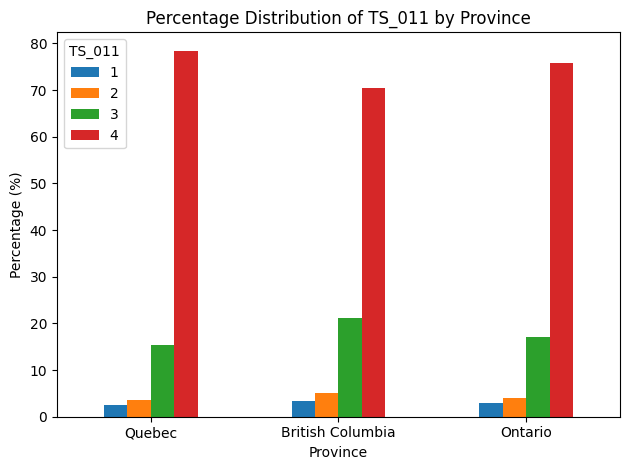


Chi-square test for TS_011 across Quebec, British Columbia, Ontario:
Chi2 statistic: 147.532042643459
P-value: 2.5720548025018837e-29
Degrees of freedom: 6
Expected frequencies:
TS_011                     1           2            3            4
PROVID                                                            
British Columbia  198.738211  286.160536  1204.235496  5195.865758
Ontario           194.697056  280.341730  1179.748500  5090.212714
Quebec            313.564733  451.497734  1900.016005  8197.921529

--- Analysis for variable: DVTY1ST ---

Percentage Distribution of DVTY1ST by Province:


DVTY1ST,1,2,3
PROVID,,,
Quebec,1.169106,0.193317,98.637577
British Columbia,1.539579,0.290487,98.169935
Ontario,1.630838,0.281690,98.087472


<Figure size 1000x600 with 0 Axes>

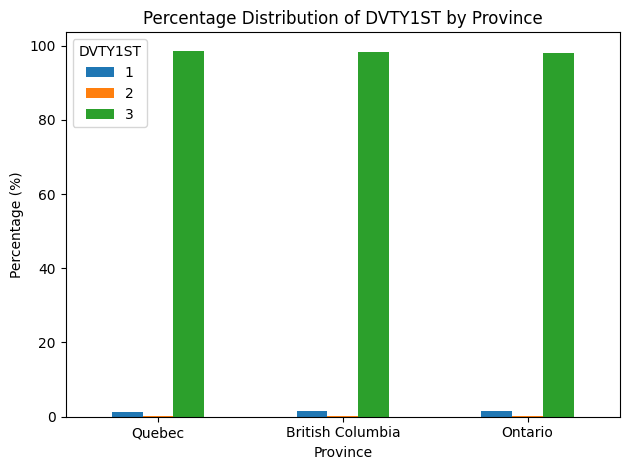


Chi-square test for DVTY1ST across Quebec, British Columbia, Ontario:
Chi2 statistic: 9.957697092283306
P-value: 0.041146329761752434
Degrees of freedom: 4
Expected frequencies:
DVTY1ST                    1          2             3
PROVID                                               
British Columbia   96.417548  16.866043   6771.716409
Ontario            94.456988  16.523088   6634.019924
Quebec            152.125464  26.610868  10684.263667


In [5]:
# make a table and bar chart to compare the percentage distribution of SS_010 (Smoker), TS_011(Will smoke in Future), DVTY1ST(Smoking Status) for "PROVID": Quebec, British Columbia and Ontario.
# calculate chisq to see if any significant differnces

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

provinces = ['Quebec', 'British Columbia', 'Ontario']
variables_to_analyze = ['SS_010', 'TS_011', 'DVTY1ST']

for var in variables_to_analyze:
  print(f"\n--- Analysis for variable: {var} ---")

  # Create a cross-tabulation table with percentage distribution for selected provinces
  crosstab_all = pd.crosstab(df['PROVID'], df[var], normalize='index') * 100
  crosstab_filtered = crosstab_all.loc[provinces]

  print(f"\nPercentage Distribution of {var} by Province:")
  display(crosstab_filtered)

  # Create a bar chart
  plt.figure(figsize=(10, 6))
  crosstab_filtered.plot(kind='bar', stacked=False)
  plt.title(f'Percentage Distribution of {var} by Province')
  plt.xlabel('Province')
  plt.ylabel('Percentage (%)')
  plt.xticks(rotation=0)
  plt.legend(title=var)
  plt.tight_layout()
  plt.show()

  # Conduct Chi-square test
  # We need a contingency table for all selected provinces together for the chi-square test
  df_filtered = df[df['PROVID'].isin(provinces)].copy()
  contingency_table = pd.crosstab(df_filtered['PROVID'], df_filtered[var])

  # Check if contingency table is valid for chi-square test
  if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and (contingency_table > 0).all().all():
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"\nChi-square test for {var} across {', '.join(provinces)}:")
    print(f"Chi2 statistic: {chi2}")
    print(f"P-value: {p}")
    print(f"Degrees of freedom: {dof}")
    print(f"Expected frequencies:\n{pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)}")
  else:
    print(f"\nChi-square test not applicable for {var} across {', '.join(provinces)} due to insufficient data or categories.")

Compare Alcoholic Drinking Behavior of Quebec, British Columbia, and Ontario

In [ ]:
#calculate descriptive statistics on QB BC and ON for comparison

provinces = ['Quebec', 'British Columbia', 'Ontario']
variables = ['ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071']

for var in variables:
  for province in provinces:
    # Create a cross-tabulation table
    crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
    crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100

    print(f"\nCross-tabulation for {var} in {province}:")
    print(crosstab)

for var in variables:
    crosstab_all = pd.crosstab(df['PROVID'], df[var], normalize='index') * 100  # Percentage for each province
    print(f"\nCross-tabulation for {var} across all provinces (percentage):")
    print(crosstab_all.loc[provinces]) #show only specified provinces

    for province in provinces:
        # Create a cross-tabulation table
        crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
        crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100
        print(f"\nCross-tabulation for {var} in {province}:")
        print(crosstab)



    # Conduct Chi-square test (if applicable)
    contingency_table = pd.crosstab(df[df['PROVID'] == province]['SS_010'], df[df['PROVID'] == province][var])
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1: #Check if contingency table is valid
      chi2, p, dof, expected = chi2_contingency(contingency_table)
      print(f"\nChi-square test for {var} in {province}:")
      print(f"Chi2 statistic: {chi2}")
      print(f"P-value: {p}")
      print(f"Degrees of freedom: {dof}")
    else:
      print(f"\nChi-square test not applicable for {var} in {province} due to insufficient data in contingency table.")


Cross-tabulation for ALC_010 in Quebec:
col_0    count  percentage
ALC_010                   
1         5667   52.167909
2         5196   47.832091

Cross-tabulation for ALC_010 in British Columbia:
col_0    count  percentage
ALC_010                   
1         3006   43.660131
2         3879   56.339869

Cross-tabulation for ALC_010 in Ontario:
col_0    count  percentage
ALC_010                   
1         3090   45.811712
2         3655   54.188288

Cross-tabulation for ALC_020 in Quebec:
col_0    count  percentage
ALC_020                   
1         6550   60.296419
3         1845   16.984258
4          698    6.425481
5         1024    9.426494
6          398    3.663813
7          242    2.227746
8           51    0.469484
9           55    0.506306

Cross-tabulation for ALC_020 in British Columbia:
col_0    count  percentage
ALC_020                   
1         4650   67.538126
3          912   13.246187
4          330    4.793028
5          542    7.872186
6          240    

In [6]:
# Make a table comparing the percentage distribution of 'ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071'
# calculate chisq to see if any significant differnces

import pandas as pd
provinces = ['Quebec', 'British Columbia', 'Ontario']
alc_variables = ['ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071']

print("\n--- Analysis for Alcoholic Drinking Behavior Variables ---")

for var in alc_variables:
    print(f"\n--- Variable: {var} ---")

    # Create a cross-tabulation table with percentage distribution for selected provinces
    # Ensure that only the selected provinces are included in the base DataFrame for crosstab
    df_filtered_prov = df[df['PROVID'].isin(provinces)].copy()

    # Handle potential missing values in the variable being analyzed
    # Optionally drop rows with NaN in the specific alcohol variable or fill them with a placeholder
    # For percentage distribution and chi-square, it's usually better to exclude NaNs
    df_filtered_prov = df_filtered_prov.dropna(subset=[var])


    if not df_filtered_prov.empty:
        crosstab_all = pd.crosstab(df_filtered_prov['PROVID'], df_filtered_prov[var], normalize='index') * 100

        print(f"\nPercentage Distribution of {var} by Province:")
        display(crosstab_all)

        # Conduct Chi-square test
        # We need a contingency table for all selected provinces together for the chi-square test
        contingency_table = pd.crosstab(df_filtered_prov['PROVID'], df_filtered_prov[var])

        # Check if contingency table is valid for chi-square test
        # Requires at least 2 rows (provinces) and 2 columns (variable categories) and no zero marginals
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and (contingency_table.sum(axis=1) > 0).all() and (contingency_table.sum(axis=0) > 0).all():
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            print(f"\nChi-square test for {var} across {', '.join(provinces)}:")
            print(f"Chi2 statistic: {chi2:.4f}")
            print(f"P-value: {p:.4f}")
            print(f"Degrees of freedom: {dof}")
            # Optional: Display expected frequencies
            # print(f"Expected frequencies:\n{pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)}")
        else:
            print(f"\nChi-square test not applicable for {var} across {', '.join(provinces)} due to insufficient data, categories, or zero marginals.")
    else:
        print(f"\nNo data available for {var} in the selected provinces after handling missing values.")


--- Analysis for Alcoholic Drinking Behavior Variables ---

--- Variable: ALC_010 ---

Percentage Distribution of ALC_010 by Province:


ALC_010,1,2
PROVID,,
British Columbia,43.660131,56.339869
Ontario,45.811712,54.188288
Quebec,52.167909,47.832091



Chi-square test for ALC_010 across Quebec, British Columbia, Ontario:
Chi2 statistic: 140.4846
P-value: 0.0000
Degrees of freedom: 2

--- Variable: ALC_020 ---

Percentage Distribution of ALC_020 by Province:


ALC_020,1,3,4,5,6,7,8,9
PROVID,,,,,,,,
British Columbia,67.538126,13.246187,4.793028,7.872186,3.485839,2.251271,0.377633,0.435730
Ontario,65.441067,16.145293,5.322461,7.546331,2.846553,1.838399,0.489251,0.370645
Quebec,60.296419,16.984258,6.425481,9.426494,3.663813,2.227746,0.469484,0.506306



Chi-square test for ALC_020 across Quebec, British Columbia, Ontario:
Chi2 statistic: 135.6713
P-value: 0.0000
Degrees of freedom: 14

--- Variable: ALC_030 ---

Percentage Distribution of ALC_030 by Province:


...


Chi-square test for ALC_050 across Quebec, British Columbia, Ontario:
Chi2 statistic: 53.1103
P-value: 0.0000
Degrees of freedom: 14

--- Variable: ALC_060 ---

Percentage Distribution of ALC_060 by Province:


ALC_060,2,8,9,10,11,12,13,14,15,16,17,18
PROVID,,,,,,,,,,,,
British Columbia,1.423384,0.421206,0.087146,0.232389,0.508351,1.655773,3.253450,83.776325,5.039942,2.643428,0.900508,0.058097
Ontario,1.734618,0.296516,0.118606,0.266864,0.385471,1.186064,2.727947,83.335804,5.159377,3.558191,1.067457,0.163084
Quebec,1.905551,0.395839,0.110467,0.377428,0.414250,1.795084,3.599374,82.592286,5.385253,2.872135,0.478689,0.073644



Chi-square test for ALC_060 across Quebec, British Columbia, Ontario:
Chi2 statistic: 70.7428
P-value: 0.0000
Degrees of freedom: 22

--- Variable: ALC_071 ---

Percentage Distribution of ALC_071 by Province:


ALC_071,1,2,3,4,5,6,7,8
PROVID,,,,,,,,
British Columbia,78.431373,8.162672,7.872186,2.527233,0.551924,0.043573,0.290487,2.120552
Ontario,78.324685,10.111193,6.790215,1.601186,0.400297,0.133432,0.326168,2.312824
Quebec,76.396944,9.076682,9.030655,1.896345,0.662800,0.128878,0.303783,2.503912



Chi-square test for ALC_071 across Quebec, British Columbia, Ontario:
Chi2 statistic: 70.7416
P-value: 0.0000
Degrees of freedom: 14


#Compare Cannibus Behavior

In [7]:
provinces = ['Quebec', 'British Columbia', 'Ontario']
variables = ['CAN_010', 'CAN_020', 'CAN_030', 'CAN_040', 'CAN_130']

for var in variables:
  for province in provinces:
    # Create a cross-tabulation table
    crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
    crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100

    print(f"\nCross-tabulation for {var} in {province}:")
    print(crosstab)

for var in variables:
    crosstab_all = pd.crosstab(df['PROVID'], df[var], normalize='index') * 100  # Percentage for each province
    print(f"\nCross-tabulation for {var} across all provinces (percentage):")
    print(crosstab_all.loc[provinces]) #show only specified provinces

    for province in provinces:
        # Create a cross-tabulation table
        crosstab = pd.crosstab(df[df['PROVID'] == province][var], columns='count')
        crosstab['percentage'] = (crosstab['count'] / crosstab['count'].sum()) * 100
        print(f"\nCross-tabulation for {var} in {province}:")
        print(crosstab)


Cross-tabulation for CAN_010 in Quebec:
col_0    count  percentage
CAN_010                   
1         1790   16.477953
2         9073   83.522047

Cross-tabulation for CAN_010 in British Columbia:
col_0    count  percentage
CAN_010                   
1         1502   21.815541
2         5383   78.184459

Cross-tabulation for CAN_010 in Ontario:
col_0    count  percentage
CAN_010                   
1         1380     20.4596
2         5365     79.5404

Cross-tabulation for CAN_020 in Quebec:
col_0    count  percentage
CAN_020                   
1         9354   86.108810
3          613    5.643008
4          153    1.408451
5          186    1.712234
6           58    0.533922
7          116    1.067845
8          121    1.113873
9          136    1.251956
10         126    1.159901

Cross-tabulation for CAN_020 in British Columbia:
col_0    count  percentage
CAN_020                   
1         5612   81.510530
3          512    7.436456
4          109    1.583152
5          167    


--- Analysis for Cannabis Behavior Variables ---

--- Variable: CAN_010 ---

Percentage Distribution of CAN_010 by Province:


CAN_010,1,2
PROVID,,
British Columbia,21.815541,78.184459
Ontario,20.459600,79.540400
Quebec,16.477953,83.522047


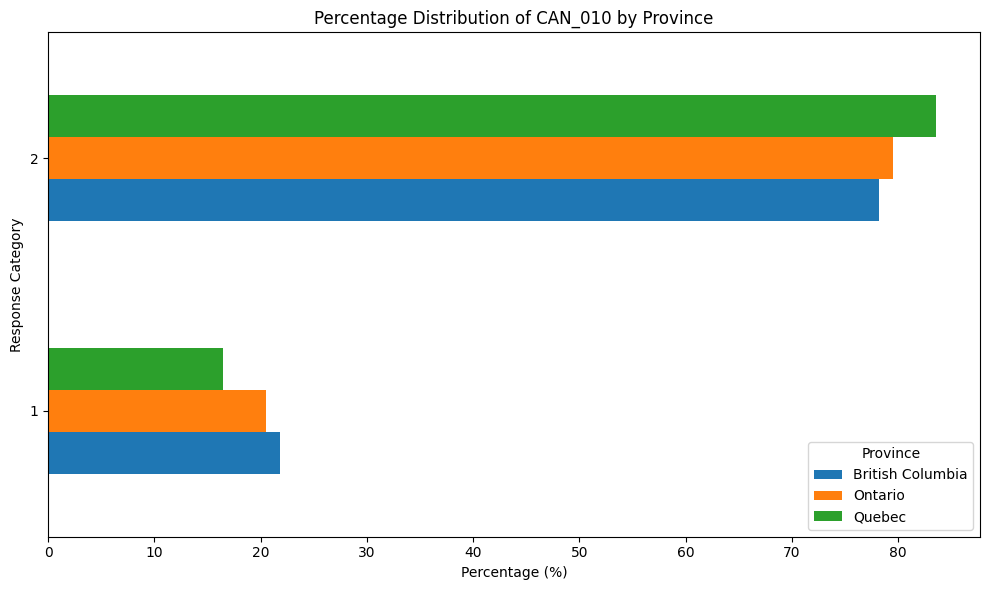


Chi-square test for CAN_010 across Quebec, British Columbia, Ontario:
Chi2 statistic: 89.3401
P-value: 0.0000
Degrees of freedom: 2

--- Variable: CAN_020 ---

Percentage Distribution of CAN_020 by Province:


CAN_020,1,3,4,5,6,7,8,9,10
PROVID,,,,,,,,,
British Columbia,81.510530,7.436456,1.583152,2.425563,1.176471,1.205519,1.394336,2.178649,1.089325
Ontario,82.668643,6.197183,1.512231,2.253521,1.052632,1.704967,1.319496,2.372128,0.919199
Quebec,86.108810,5.643008,1.408451,1.712234,0.533922,1.067845,1.113873,1.251956,1.159901


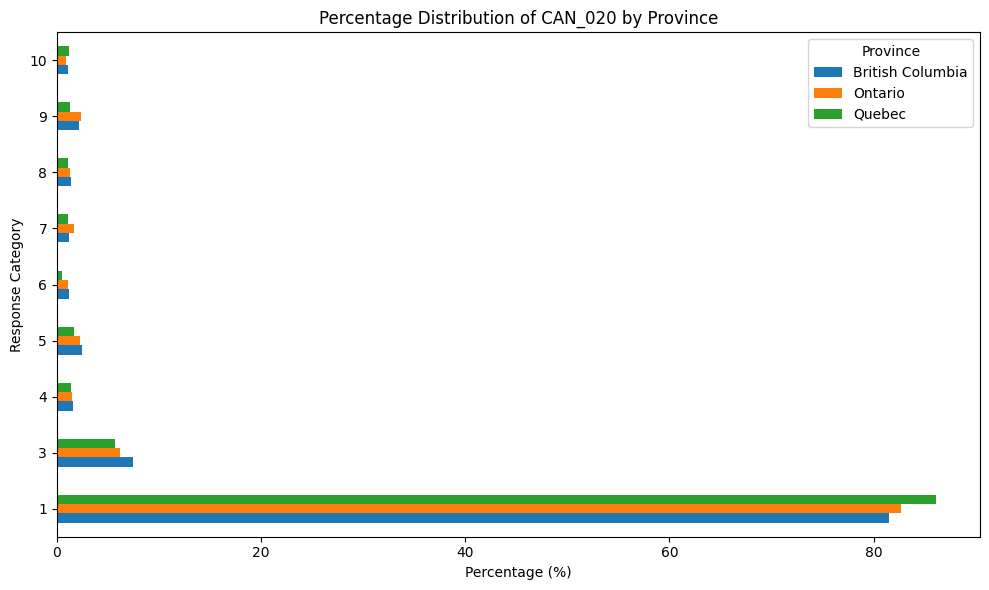


Chi-square test for CAN_020 across Quebec, British Columbia, Ontario:
Chi2 statistic: 125.5972
P-value: 0.0000
Degrees of freedom: 16

--- Variable: CAN_030 ---

Percentage Distribution of CAN_030 by Province:


CAN_030,2,8,9,10,11,12,13,14,15,16,17,18
PROVID,,,,,,,,,,,,
British Columbia,0.377633,0.435730,0.058097,0.435730,0.885984,2.556282,4.415396,83.703704,4.008715,2.309368,0.740741,0.072622
Ontario,0.429948,0.311342,0.133432,0.207561,0.578206,1.630838,3.009637,85.025945,4.373610,3.128243,1.082283,0.088955
Quebec,0.331400,0.322195,0.138083,0.119672,0.266961,1.344012,2.706435,87.931511,3.967596,2.384240,0.460278,0.027617


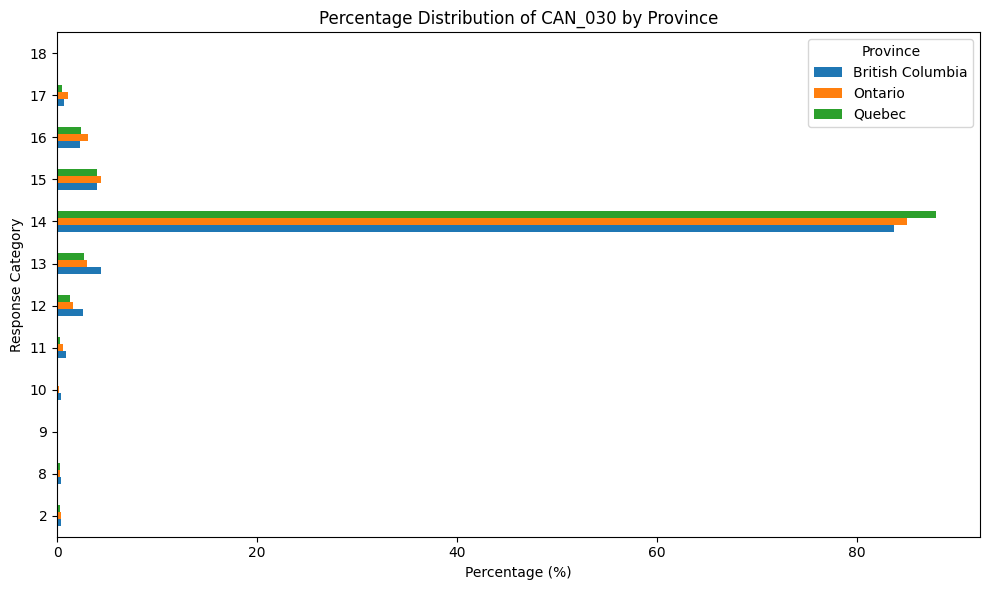


Chi-square test for CAN_030 across Quebec, British Columbia, Ontario:
Chi2 statistic: 179.7053
P-value: 0.0000
Degrees of freedom: 22

--- Variable: CAN_040 ---

Percentage Distribution of CAN_040 by Province:


CAN_040,1,2,3,4,5,6,7
PROVID,,,,,,,
British Columbia,87.494553,5.751634,2.135076,1.161946,0.813362,2.120552,0.522876
Ontario,87.916976,4.862861,2.120089,1.141586,1.008154,2.401779,0.548554
Quebec,91.181073,4.032035,1.362423,0.754856,0.681211,1.233545,0.754856


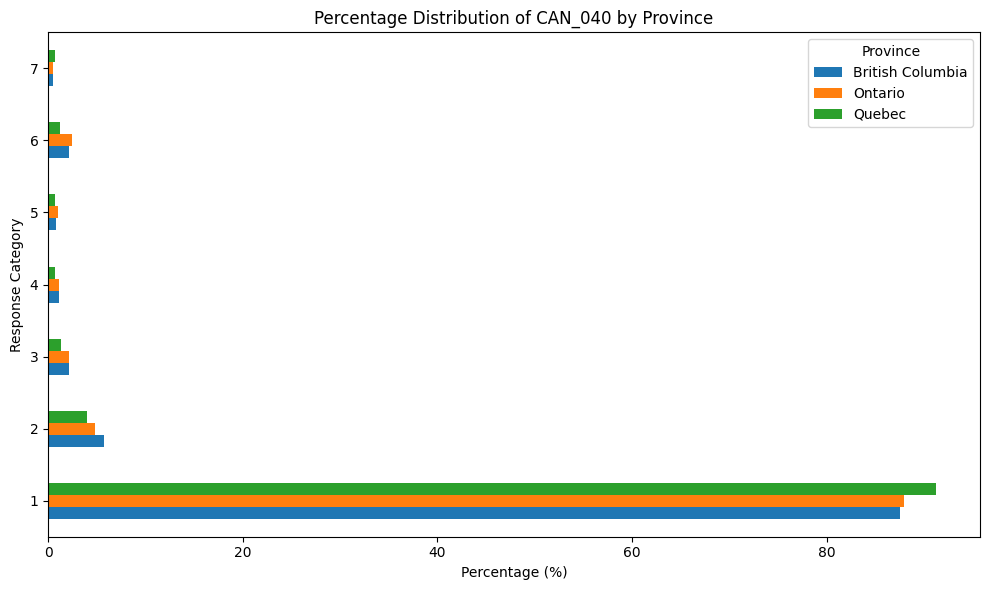


Chi-square test for CAN_040 across Quebec, British Columbia, Ontario:
Chi2 statistic: 111.2821
P-value: 0.0000
Degrees of freedom: 12

--- Variable: CAN_130 ---

Percentage Distribution of CAN_130 by Province:


CAN_130,1,2,3,4
PROVID,,,,
British Columbia,83.892520,5.446623,0.566449,10.094408
Ontario,84.759081,6.152706,0.711638,8.376575
Quebec,87.913100,4.427874,0.478689,7.180337


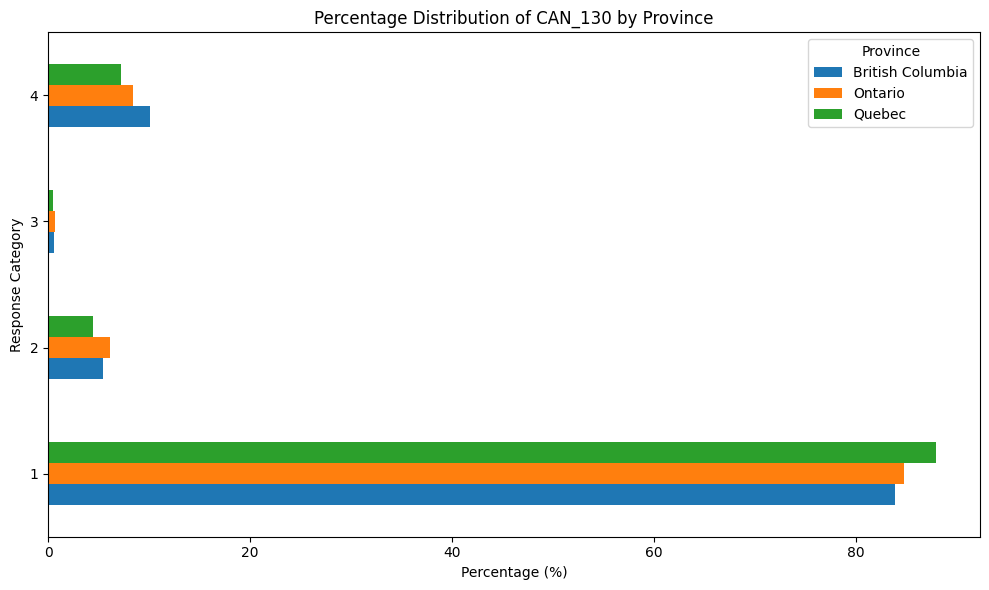


Chi-square test for CAN_130 across Quebec, British Columbia, Ontario:
Chi2 statistic: 81.4241
P-value: 0.0000
Degrees of freedom: 6


In [8]:
# prompt: Make a table and horizontal bar chart comparing the percentage distribution of 'CAN_010', 'CAN_020', 'CAN_030', 'CAN_040', 'CAN_130' for "PROVID": Quebec, British Columbia and Ontario.
# # calculate chisq to see if any significant differnces

import pandas as pd
import matplotlib.pyplot as plt
provinces = ['Quebec', 'British Columbia', 'Ontario']
cannabis_variables = ['CAN_010', 'CAN_020', 'CAN_030', 'CAN_040', 'CAN_130']

print("\n--- Analysis for Cannabis Behavior Variables ---")

for var in cannabis_variables:
    print(f"\n--- Variable: {var} ---")

    # Filter DataFrame for selected provinces and drop rows with NaN in the variable
    df_filtered_prov = df[df['PROVID'].isin(provinces)].copy()
    df_filtered_prov = df_filtered_prov.dropna(subset=[var])


    if not df_filtered_prov.empty:
        # Create a cross-tabulation table with percentage distribution for selected provinces
        crosstab_all = pd.crosstab(df_filtered_prov['PROVID'], df_filtered_prov[var], normalize='index') * 100

        print(f"\nPercentage Distribution of {var} by Province:")
        display(crosstab_all)

        # Create a horizontal bar chart for percentage distribution
        plt.figure(figsize=(10, 6))
        # Transpose the crosstab to have provinces on the y-axis for a horizontal bar chart
        crosstab_all.T.plot(kind='barh', stacked=False, ax=plt.gca())
        plt.title(f'Percentage Distribution of {var} by Province')
        plt.xlabel('Percentage (%)')
        plt.ylabel('Response Category')
        plt.legend(title='Province')
        plt.tight_layout()
        plt.show()


        # Conduct Chi-square test
        contingency_table = pd.crosstab(df_filtered_prov['PROVID'], df_filtered_prov[var])

        # Check if contingency table is valid for chi-square test
        if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and (contingency_table.sum(axis=1) > 0).all() and (contingency_table.sum(axis=0) > 0).all():
            chi2, p, dof, expected = chi2_contingency(contingency_table)
            print(f"\nChi-square test for {var} across {', '.join(provinces)}:")
            print(f"Chi2 statistic: {chi2:.4f}")
            print(f"P-value: {p:.4f}")
            print(f"Degrees of freedom: {dof}")
            # Optional: Display expected frequencies
            # print(f"Expected frequencies:\n{pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)}")
        else:
            print(f"\nChi-square test not applicable for {var} across {', '.join(provinces)} due to insufficient data, categories, or zero marginals.")
    else:
        print(f"\nNo data available for {var} in the selected provinces after handling missing values.")

Examine the Gender Differences, Urban/Rural on Smoking, Alcohol drinking and Cannibus use behaviors

In [ ]:
# prompt: cross tabulations for DVGENDER DVURBAN on 'SS_010', 'TS_011', 'DVTY1ST', 'DVTY2ST', 'DVLAST30', 'DVAMTSMK'

import pandas as pd
# Assuming 'df' is your DataFrame and it's already loaded

#Cross Tabulations for DVGENDER, DVURBAN
variables = ['SS_010', 'TS_011', 'DVTY1ST', 'DVTY2ST', 'DVLAST30', 'DVAMTSMK']

for var in variables:
    #Cross Tabulation for DVGENDER
    crosstab_gender = pd.crosstab(df['DVGENDER'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation for {var} and DVGENDER (percentage):")
    print(crosstab_gender)

    #Chi-square test for DVGENDER
    contingency_table_gender = pd.crosstab(df['DVGENDER'], df[var])
    if contingency_table_gender.shape[0] > 1 and contingency_table_gender.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_gender)
        print(f"\nChi-square test for {var} and DVGENDER:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} and DVGENDER due to insufficient data in contingency table.")

    #Cross Tabulation for DVURBAN
    crosstab_urban = pd.crosstab(df['DVURBAN'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation for {var} and DVURBAN (percentage):")
    print(crosstab_urban)

    #Chi-square test for DVURBAN
    contingency_table_urban = pd.crosstab(df['DVURBAN'], df[var])
    if contingency_table_urban.shape[0] > 1 and contingency_table_urban.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_urban)
        print(f"\nChi-square test for {var} and DVURBAN:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} and DVURBAN due to insufficient data in contingency table.")



Cross-tabulation for SS_010 and DVGENDER (percentage):
SS_010            1          2
DVGENDER                      
1         16.401649  83.598351
2         16.349328  83.650672

Chi-square test for SS_010 and DVGENDER:
Chi2 statistic: 0.026463757448872704
P-value: 0.8707728753731035
Degrees of freedom: 1

Cross-tabulation for SS_010 and DVURBAN (percentage):
SS_010           1          2
DVURBAN                      
1        15.275228  84.724772
2        21.095581  78.904419

Chi-square test for SS_010 and DVURBAN:
Chi2 statistic: 230.84267680131703
P-value: 3.904543428662461e-52
Degrees of freedom: 1

Cross-tabulation for TS_011 and DVGENDER (percentage):
TS_011           1         2          3          4
DVGENDER                                          
1         2.753239  5.550648  20.064046  71.632067
2         3.634166  4.300283  17.705140  74.360410

Chi-square test for TS_011 and DVGENDER:
Chi2 statistic: 144.79640730848382
P-value: 3.4925890130057606e-31
Degrees of freedom

In [ ]:
# prompt: Examine the DVGENDER DVURBAN on 'ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071'

import pandas as pd
# Examine the DVGENDER DVURBAN on 'ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071'

variables = ['ALC_010', 'ALC_020', 'ALC_030', 'ALC_040', 'ALC_050', 'ALC_060', 'ALC_071']

for var in variables:
    # Create a cross-tabulation table for Gender
    crosstab_gender = pd.crosstab(df['DVGENDER'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation for {var} by Gender (percentage):")
    print(crosstab_gender)

    # Conduct Chi-square test for Gender (if applicable)
    contingency_table_gender = pd.crosstab(df['DVGENDER'], df[var])
    if contingency_table_gender.shape[0] > 1 and contingency_table_gender.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_gender)
        print(f"\nChi-square test for {var} by Gender:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} by Gender due to insufficient data.")

    # Create a cross-tabulation table for Urban/Rural
    crosstab_urban = pd.crosstab(df['DVURBAN'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation for {var} by Urban/Rural (percentage):")
    print(crosstab_urban)

    # Conduct Chi-square test for Urban/Rural (if applicable)
    contingency_table_urban = pd.crosstab(df['DVURBAN'], df[var])
    if contingency_table_urban.shape[0] > 1 and contingency_table_urban.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_urban)
        print(f"\nChi-square test for {var} by Urban/Rural:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} by Urban/Rural due to insufficient data.")



Cross-tabulation for ALC_010 by Gender (percentage):
ALC_010           1          2
DVGENDER                      
1         48.409894  51.590106
2         44.856755  55.143245

Chi-square test for ALC_010 by Gender:
Chi2 statistic: 76.4342744509301
P-value: 2.276654331108606e-18
Degrees of freedom: 1

Cross-tabulation for ALC_010 by Urban/Rural (percentage):
ALC_010          1          2
DVURBAN                      
1        45.819634  54.180366
2        49.092803  50.907197

Chi-square test for ALC_010 by Urban/Rural:
Chi2 statistic: 40.130052450553876
P-value: 2.37605376540795e-10
Degrees of freedom: 1

Cross-tabulation for ALC_020 by Gender (percentage):
ALC_020           1          3         4         5         6         7  \
DVGENDER                                                                 
1         62.374853  15.970995  5.999706  9.908716  3.342167  1.976590   
2         67.357345  14.012025  4.957557  7.091488  3.106579  2.189932   

ALC_020          8         9  
DVG

In [ ]:
# Examine the DVGENDER, DVURBAN on 'CAN_010', 'CAN_020', 'CAN_030', 'CAN_040', 'CAN_130']

variables = ['CAN_010', 'CAN_020', 'CAN_030', 'CAN_040', 'CAN_130']

for var in variables:
    # Cross-tabulation with DVGENDER
    gender_crosstab = pd.crosstab(df['DVGENDER'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation of {var} with DVGENDER (percentage):")
    print(gender_crosstab)

    # Chi-square test with DVGENDER
    contingency_table_gender = pd.crosstab(df['DVGENDER'], df[var])
    if contingency_table_gender.shape[0] > 1 and contingency_table_gender.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_gender)
        print(f"\nChi-square test for {var} and DVGENDER:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} and DVGENDER due to insufficient data.")

    # Cross-tabulation with DVURBAN
    urban_crosstab = pd.crosstab(df['DVURBAN'], df[var], normalize='index') * 100
    print(f"\nCross-tabulation of {var} with DVURBAN (percentage):")
    print(urban_crosstab)

    # Chi-square test with DVURBAN
    contingency_table_urban = pd.crosstab(df['DVURBAN'], df[var])
    if contingency_table_urban.shape[0] > 1 and contingency_table_urban.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(contingency_table_urban)
        print(f"\nChi-square test for {var} and DVURBAN:")
        print(f"Chi2 statistic: {chi2}")
        print(f"P-value: {p}")
        print(f"Degrees of freedom: {dof}")
    else:
        print(f"\nChi-square test not applicable for {var} and DVURBAN due to insufficient data.")



Cross-tabulation of CAN_010 with DVGENDER (percentage):
CAN_010           1          2
DVGENDER                      
1         21.889723  78.110277
2         20.127918  79.872082

Chi-square test for CAN_010 and DVGENDER:
Chi2 statistic: 28.208971431962464
P-value: 1.0889864258159308e-07
Degrees of freedom: 1

Cross-tabulation of CAN_010 with DVURBAN (percentage):
CAN_010          1          2
DVURBAN                      
1        20.327975  79.672025
2        23.422172  76.577828

Chi-square test for CAN_010 and DVURBAN:
Chi2 statistic: 53.92362809287277
P-value: 2.084359780735647e-13
Degrees of freedom: 1

Cross-tabulation of CAN_020 with DVGENDER (percentage):
CAN_020          1         3         4         5         6         7   \
DVGENDER                                                                
1         81.364105  7.534600  1.582744  2.606007  0.868669  1.299323   
2         83.344141  5.464513  1.585711  2.013087  0.884225  1.447182   

CAN_020         8         9     